In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA RTX A6000


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA RTX A6000


Signal: 500 values
Range: [-1.000, 1.000]
Normalized range: [0.000, 1.000]
Tokens: 1500 (= 500 values × 3 digits)
First 15 tokens: [5, 0, 0, 5, 3, 1, 5, 6, 2, 5, 9, 3, 6, 2, 4]
First 5 values: [0.         0.06279052 0.12533323 0.18738131 0.24868989]
Reconstructed: [0.    0.062 0.124 0.186 0.248]


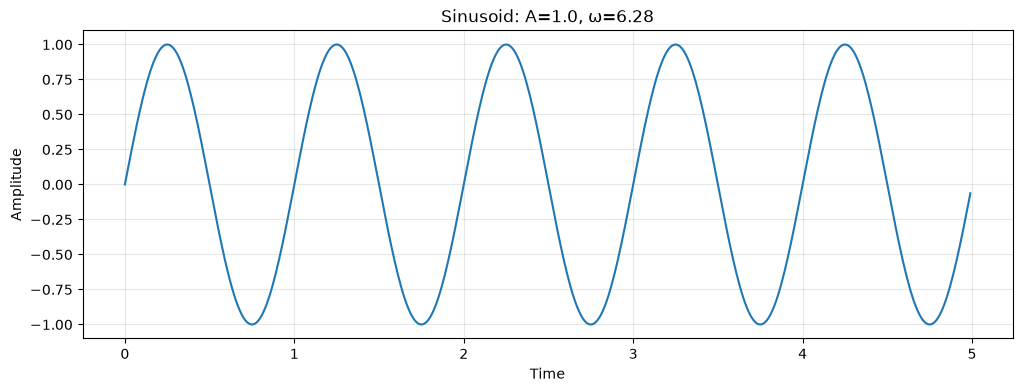

In [2]:
# %% Cell 2 - Generate sinusoidal data

def generate_sinusoid(A, omega, length, dt=0.01, noise_std=0.0):
    """Generate a sinusoidal signal."""
    t = np.arange(length) * dt
    y = A * np.sin(omega * t)
    if noise_std > 0:
        y += np.random.normal(0, noise_std, length)
    return t, y

def normalize_signal(y, y_min=None, y_max=None):
    """Normalize signal to [0, 1]."""
    if y_min is None:
        y_min = y.min()
    if y_max is None:
        y_max = y.max()
    return (y - y_min) / (y_max - y_min), y_min, y_max

def denormalize_signal(y_norm, y_min, y_max):
    """Reverse normalization."""
    return y_norm * (y_max - y_min) + y_min

def discretize(y_norm, precision=3, base=10):
    """Convert normalized values to digit tokens (tsGT style)."""
    tokens = []
    for val in y_norm:
        val = np.clip(val, 0, 1 - 1e-9)
        digits = []
        remaining = val
        for _ in range(precision):
            remaining *= base
            digit = int(remaining)
            digits.append(digit)
            remaining -= digit
        tokens.extend(digits)
    return tokens

def undiscretize(tokens, precision=3, base=10):
    """Convert digit tokens back to values."""
    values = []
    for i in range(0, len(tokens), precision):
        chunk = tokens[i:i+precision]
        if len(chunk) < precision:
            break
        val = 0
        for j, d in enumerate(chunk):
            val += d / (base ** (j + 1))
        values.append(val)
    return np.array(values)

# Test: generate and visualize
A, omega = 1.0, 2 * np.pi  # amplitude 1, frequency 1 Hz
t, y = generate_sinusoid(A, omega, length=500)
y_norm, y_min, y_max = normalize_signal(y)
tokens = discretize(y_norm)

print(f"Signal: {len(y)} values")
print(f"Range: [{y.min():.3f}, {y.max():.3f}]")
print(f"Normalized range: [{y_norm.min():.3f}, {y_norm.max():.3f}]")
print(f"Tokens: {len(tokens)} (= {len(y)} values × 3 digits)")
print(f"First 15 tokens: {tokens[:15]}")
print(f"First 5 values: {y[:5]}")
print(f"Reconstructed: {denormalize_signal(undiscretize(tokens[:15]), y_min, y_max)}")

plt.figure(figsize=(12, 4))
plt.plot(t, y)
plt.title(f'Sinusoid: A={A}, ω={omega:.2f}')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# %% Cell 3 - Transformer model (adapted for digit tokens)

block_size = 512
batch_size = 16
learning_rate = 0.001
weight_decay = 1e-3
dropout = 0.0
vocab_size = 10  # digits 0-9
n_head = 4
n_layer = 4
n_embd = 128

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * C ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),  # GeLU like tsGT, not ReLU
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class SignalTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

model = SignalTransformer().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {n_head} heads, {n_layer} layers, {n_embd}d")
print(f"Total parameters: {total_params:,}")
print(f"Vocab size: {vocab_size} (digits 0-9)")
print(f"Activation: GeLU")

Model: 4 heads, 4 layers, 128d
Total parameters: 859,914
Vocab size: 10 (digits 0-9)
Activation: GeLU


Generated 500 signals
Each signal: 256 values = 768 tokens
Fixed normalization: [-1.0, 1.0] → [0, 1]


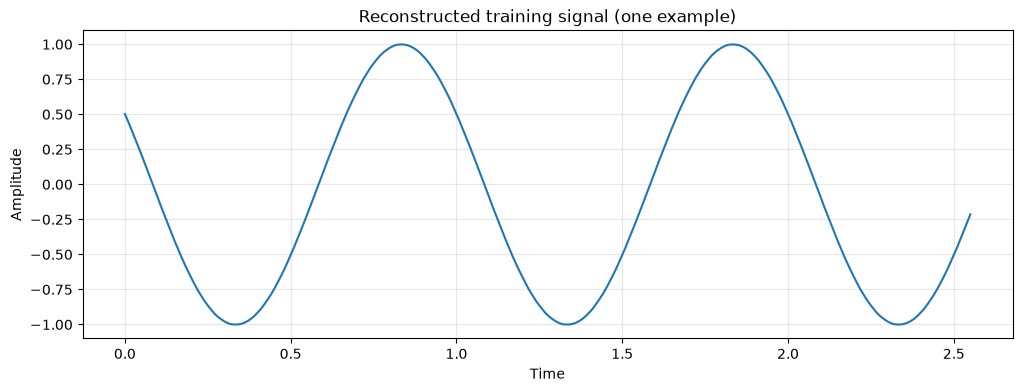

In [4]:
# %% Cell 4 - Generate training data

def generate_training_signals(num_signals, signal_length, A, omega, dt=0.01):
    """Generate multiple sinusoidal signals as token sequences."""
    all_tokens = []
    
    for i in range(num_signals):
        # Small phase shift per signal so they're not identical
        phase = np.random.uniform(0, 2 * np.pi)
        t = np.arange(signal_length) * dt
        y = A * np.sin(omega * t + phase)
        
        # Normalize (use fixed range based on amplitude)
        y_norm = (y - (-A)) / (2 * A)  # maps [-A, A] to [0, 1]
        
        tokens = discretize(y_norm)
        all_tokens.append(torch.tensor(tokens, dtype=torch.long))
    
    return all_tokens

# Generate signals
A = 1.0
omega = 2 * np.pi  # 1 Hz
num_signals = 500
signal_length = 256  # 256 values = 768 tokens per signal

signals = generate_training_signals(num_signals, signal_length, A, omega)

print(f"Generated {len(signals)} signals")
print(f"Each signal: {signal_length} values = {len(signals[0])} tokens")
print(f"Fixed normalization: [{-A}, {A}] → [0, 1]")

# Verify one signal
test_tokens = signals[0].numpy().tolist()
test_values = undiscretize(test_tokens)
test_denorm = test_values * (2 * A) + (-A)

plt.figure(figsize=(12, 4))
t = np.arange(signal_length) * 0.01
plt.plot(t, test_denorm)
plt.title('Reconstructed training signal (one example)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.show()

Training...
  iter 0: train 2.3554, val 2.3592
  iter 1000: train 0.6818, val 0.7016
  iter 2000: train 0.1546, val 0.1979
  iter 3000: train 0.1111, val 0.1523
  iter 4000: train 0.0831, val 0.1299
  iter 5000: train 0.0742, val 0.1272
  iter 6000: train 0.0675, val 0.1208
  iter 7000: train 0.0576, val 0.1169
  iter 8000: train 0.0516, val 0.1134
  iter 9000: train 0.0477, val 0.1146
  iter 10000: train 0.0453, val 0.1083
  iter 11000: train 0.0417, val 0.1069
  iter 12000: train 0.0410, val 0.1083
  iter 13000: train 0.0396, val 0.1124
  iter 14000: train 0.0365, val 0.1160
  iter 15000: train 0.0351, val 0.1130
  iter 16000: train 0.0332, val 0.1101
  iter 17000: train 0.0345, val 0.1132
  iter 18000: train 0.0323, val 0.1162
  iter 19000: train 0.0309, val 0.1123
  iter 19999: train 0.0289, val 0.1148

Training complete!


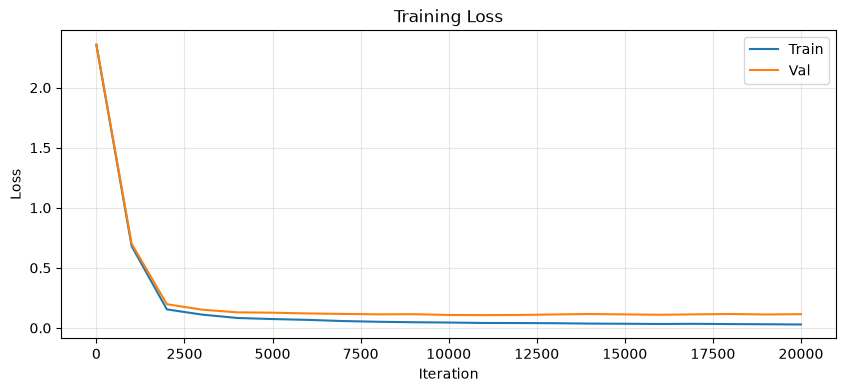

In [5]:
# %% Cell 5 - Training

def get_batch(sequences, split='train'):
    n = int(0.9 * len(sequences))
    data = sequences[:n] if split == 'train' else sequences[n:]
    while True:
        seq_indices = torch.randint(len(data), (batch_size,))
        x_batch, y_batch = [], []
        for idx in seq_indices:
            sequence = data[idx]
            if len(sequence) >= block_size + 1:
                start_idx = torch.randint(0, len(sequence) - block_size, (1,))
                x_batch.append(sequence[start_idx:start_idx + block_size])
                y_batch.append(sequence[start_idx + 1:start_idx + block_size + 1])
        if len(x_batch) > 0:
            return torch.stack(x_batch).to(device), torch.stack(y_batch).to(device)

eval_iters = 200
eval_interval = 1000

@torch.no_grad()
def estimate_loss(model, sequences):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(sequences, split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# Train
num_iterations = 20000
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

print("Training...")
history = {'train': [], 'val': [], 'iter': []}

for iter in range(num_iterations):
    xb, yb = get_batch(signals, 'train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    
    if iter % eval_interval == 0 or iter == num_iterations - 1:
        losses = estimate_loss(model, signals)
        history['train'].append(losses['train'].item())
        history['val'].append(losses['val'].item())
        history['iter'].append(iter)
        print(f"  iter {iter}: train {losses['train']:.4f}, val {losses['val']:.4f}")

# Save model
save_dir = Path(os.path.expanduser('~/research-project/models/sinusoid'))
save_dir.mkdir(parents=True, exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
    'config': {'A': A, 'omega': omega, 'n_head': n_head, 'n_layer': n_layer,
               'n_embd': n_embd, 'signal_length': signal_length, 
               'num_signals': num_signals, 'iterations': num_iterations},
}, save_dir / 'sinusoid_level1.pt')

print("\nTraining complete!")

# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(history['iter'], history['train'], label='Train')
plt.plot(history['iter'], history['val'], label='Val')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

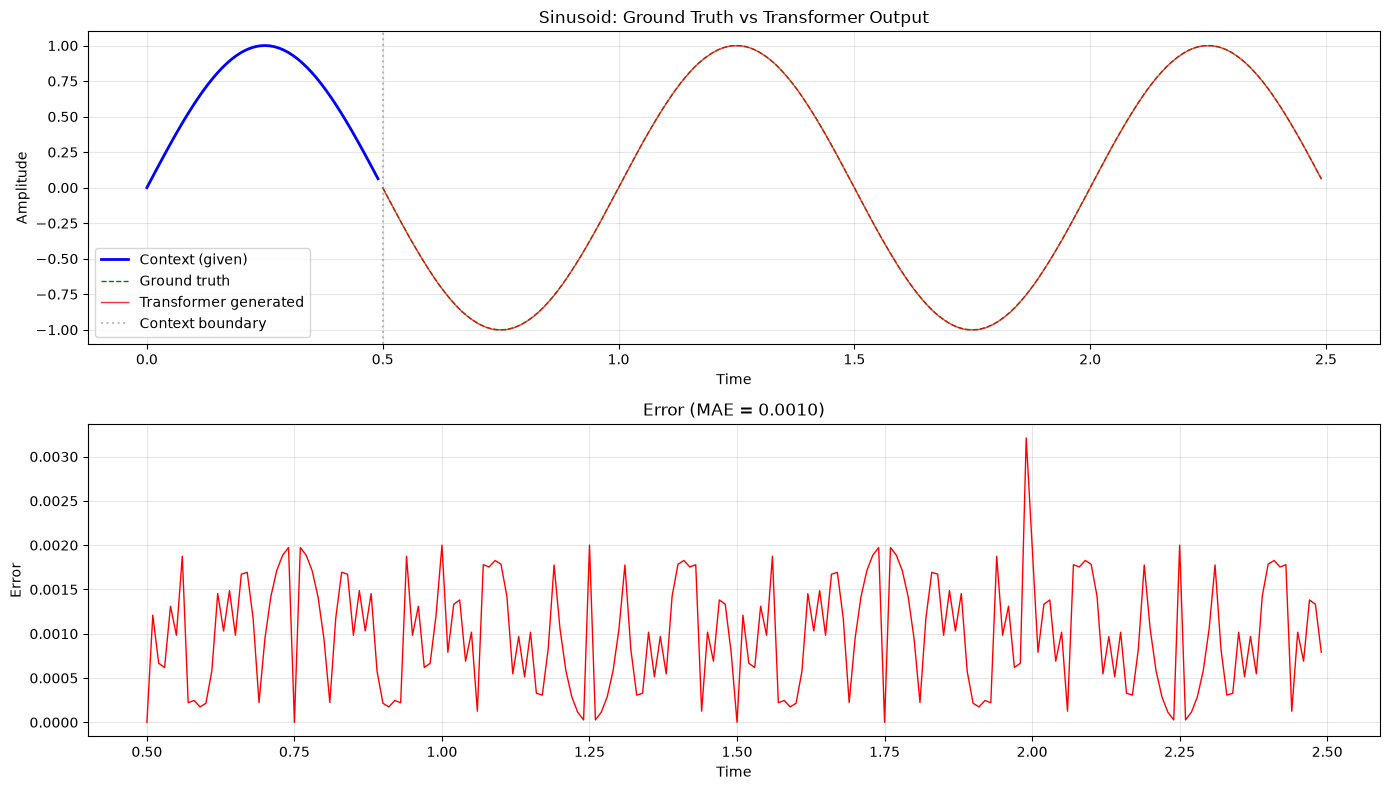

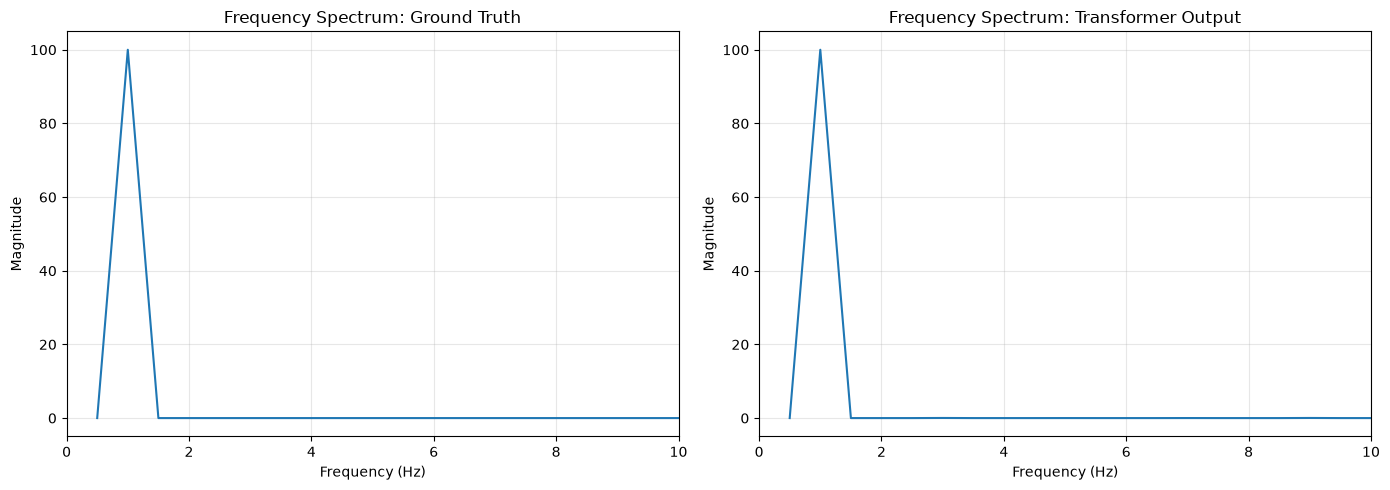

MAE: 0.0010
True frequency: 1.0 Hz
True amplitude: 1.0


In [6]:
# %% Cell 6 - Generate and evaluate

model.eval()
A = 1.0

# Give the model a context (first 50 values = 150 tokens)
t_context = np.arange(50) * 0.01
y_context = A * np.sin(2 * np.pi * t_context)
y_context_norm = (y_context - (-A)) / (2 * A)
context_tokens = discretize(y_context_norm)
context_tensor = torch.tensor(context_tokens, dtype=torch.long).unsqueeze(0).to(device)

# Generate 200 more values = 600 tokens
num_generate = 600
with torch.no_grad():
    generated = model.generate(context_tensor, num_generate)

all_tokens = generated.tolist()[0]
all_values_norm = undiscretize(all_tokens)
all_values = all_values_norm * (2 * A) + (-A)

# Split into context and generated
context_values = all_values[:50]
generated_values = all_values[50:]

# Ground truth for comparison
t_full = np.arange(len(all_values)) * 0.01
y_true = A * np.sin(2 * np.pi * t_full)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: full signal
axes[0].plot(t_full[:50], y_true[:50], 'b-', linewidth=2, label='Context (given)')
axes[0].plot(t_full[50:len(all_values)], y_true[50:len(all_values)], 'g--', linewidth=1, label='Ground truth')
axes[0].plot(t_full[50:len(all_values)], generated_values[:len(t_full)-50], 'r-', linewidth=1, alpha=0.8, label='Transformer generated')
axes[0].axvline(x=0.50, color='gray', linestyle=':', alpha=0.5, label='Context boundary')
axes[0].set_title('Sinusoid: Ground Truth vs Transformer Output')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: error
error = y_true[50:len(all_values)] - generated_values[:len(t_full)-50]
axes[1].plot(t_full[50:len(all_values)], error, 'r-', linewidth=1)
axes[1].set_title(f'Error (MAE = {np.mean(np.abs(error)):.4f})')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/research-project/plots/sinusoid_level1_generation.png'), dpi=150)
plt.show()

# Frequency analysis
from numpy.fft import fft, fftfreq

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, signal, title in [(axes[0], y_true[50:len(all_values)], 'Ground Truth'),
                           (axes[1], generated_values[:len(t_full)-50], 'Transformer Output')]:
    N = len(signal)
    freqs = fftfreq(N, d=0.01)
    spectrum = np.abs(fft(signal))
    
    # Only positive frequencies
    mask = freqs > 0
    ax.plot(freqs[mask], spectrum[mask])
    ax.set_title(f'Frequency Spectrum: {title}')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude')
    ax.set_xlim(0, 10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/research-project/plots/sinusoid_level1_spectrum.png'), dpi=150)
plt.show()

print(f"MAE: {np.mean(np.abs(error)):.4f}")
print(f"True frequency: 1.0 Hz")
print(f"True amplitude: {A}")

In [7]:
# %% Cell 7 - Level 2: Sinusoid + Gaussian Noise

# Generate noisy training data
noise_levels = [0.0, 0.1, 0.2, 0.5, 1.0]  # sigma values
results_level2 = {}

for sigma in noise_levels:
    print(f"\n{'='*60}")
    print(f"Training with noise sigma = {sigma}")
    print(f"{'='*60}")
    
    # Generate noisy signals
    noisy_signals = []
    for i in range(500):
        phase = np.random.uniform(0, 2 * np.pi)
        t = np.arange(256) * 0.01
        y = A * np.sin(omega * t + phase) + np.random.normal(0, sigma, 256)
        
        # Normalize with wider range to accommodate noise
        y_range = A + 3 * sigma  # 3 sigma should capture most values
        y_norm = (y - (-y_range)) / (2 * y_range)
        y_norm = np.clip(y_norm, 0, 1 - 1e-9)
        
        tokens = discretize(y_norm)
        noisy_signals.append(torch.tensor(tokens, dtype=torch.long))
    
    # Train a fresh model
    model2 = SignalTransformer().to(device)
    optimizer2 = torch.optim.AdamW(model2.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    for iter in range(20000):
        xb, yb = get_batch(noisy_signals, 'train')
        logits, loss = model2(xb, yb)
        optimizer2.zero_grad(set_to_none=True)
        loss.backward()
        optimizer2.step()
        
        if iter % 5000 == 0 or iter == 19999:
            losses = estimate_loss(model2, noisy_signals)
            print(f"  iter {iter}: train {losses['train']:.4f}, val {losses['val']:.4f}")
    
    # Generate output
    model2.eval()
    y_range = A + 3 * sigma
    t_ctx = np.arange(50) * 0.01
    y_ctx = A * np.sin(omega * t_ctx)  # clean context
    y_ctx_norm = (y_ctx - (-y_range)) / (2 * y_range)
    y_ctx_norm = np.clip(y_ctx_norm, 0, 1 - 1e-9)
    ctx_tokens = discretize(y_ctx_norm)
    ctx_tensor = torch.tensor(ctx_tokens, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        gen = model2.generate(ctx_tensor, 600)
    
    gen_tokens = gen.tolist()[0]
    gen_values_norm = undiscretize(gen_tokens)
    gen_values = gen_values_norm * (2 * y_range) + (-y_range)
    
    generated = gen_values[50:]
    t_gen = np.arange(len(generated)) * 0.01
    y_true_gen = A * np.sin(omega * (t_gen + 0.50))
    
    mae = np.mean(np.abs(y_true_gen[:len(generated)] - generated[:len(y_true_gen)]))
    
    results_level2[sigma] = {
        'mae': mae,
        'generated': generated,
        'y_true': y_true_gen,
    }
    
    print(f"  MAE vs clean sinusoid: {mae:.4f}")
    
    # Save model
    torch.save(model2.state_dict(), 
               os.path.expanduser(f'~/research-project/models/sinusoid/level2_sigma{sigma}.pt'))

print("\n\nAll noise levels complete!")
print(f"\n{'Sigma':<10} {'MAE vs clean':<15}")
print("-" * 25)
for sigma in noise_levels:
    print(f"{sigma:<10} {results_level2[sigma]['mae']:<15.4f}")


Training with noise sigma = 0.0
  iter 0: train 2.3575, val 2.3574
  iter 5000: train 0.0782, val 0.0985
  iter 10000: train 0.0463, val 0.0749
  iter 15000: train 0.0350, val 0.0680
  iter 19999: train 0.0293, val 0.0638
  MAE vs clean sinusoid: 0.0293

Training with noise sigma = 0.1
  iter 0: train 2.3908, val 2.3889
  iter 5000: train 1.6910, val 1.7429
  iter 10000: train 1.0972, val 2.7899
  iter 15000: train 0.7787, val 4.3424
  iter 19999: train 0.6591, val 5.2220
  MAE vs clean sinusoid: 0.0942

Training with noise sigma = 0.2
  iter 0: train 2.3838, val 2.3870
  iter 5000: train 1.8534, val 1.8847
  iter 10000: train 1.3268, val 2.6261
  iter 15000: train 1.0105, val 4.0236
  iter 19999: train 0.8901, val 4.9270
  MAE vs clean sinusoid: 0.1666

Training with noise sigma = 0.5
  iter 0: train 2.3585, val 2.3627
  iter 5000: train 1.9949, val 2.0489
  iter 10000: train 1.2996, val 3.2678
  iter 15000: train 1.0266, val 4.6541
  iter 19999: train 0.9189, val 5.5421
  MAE vs cle

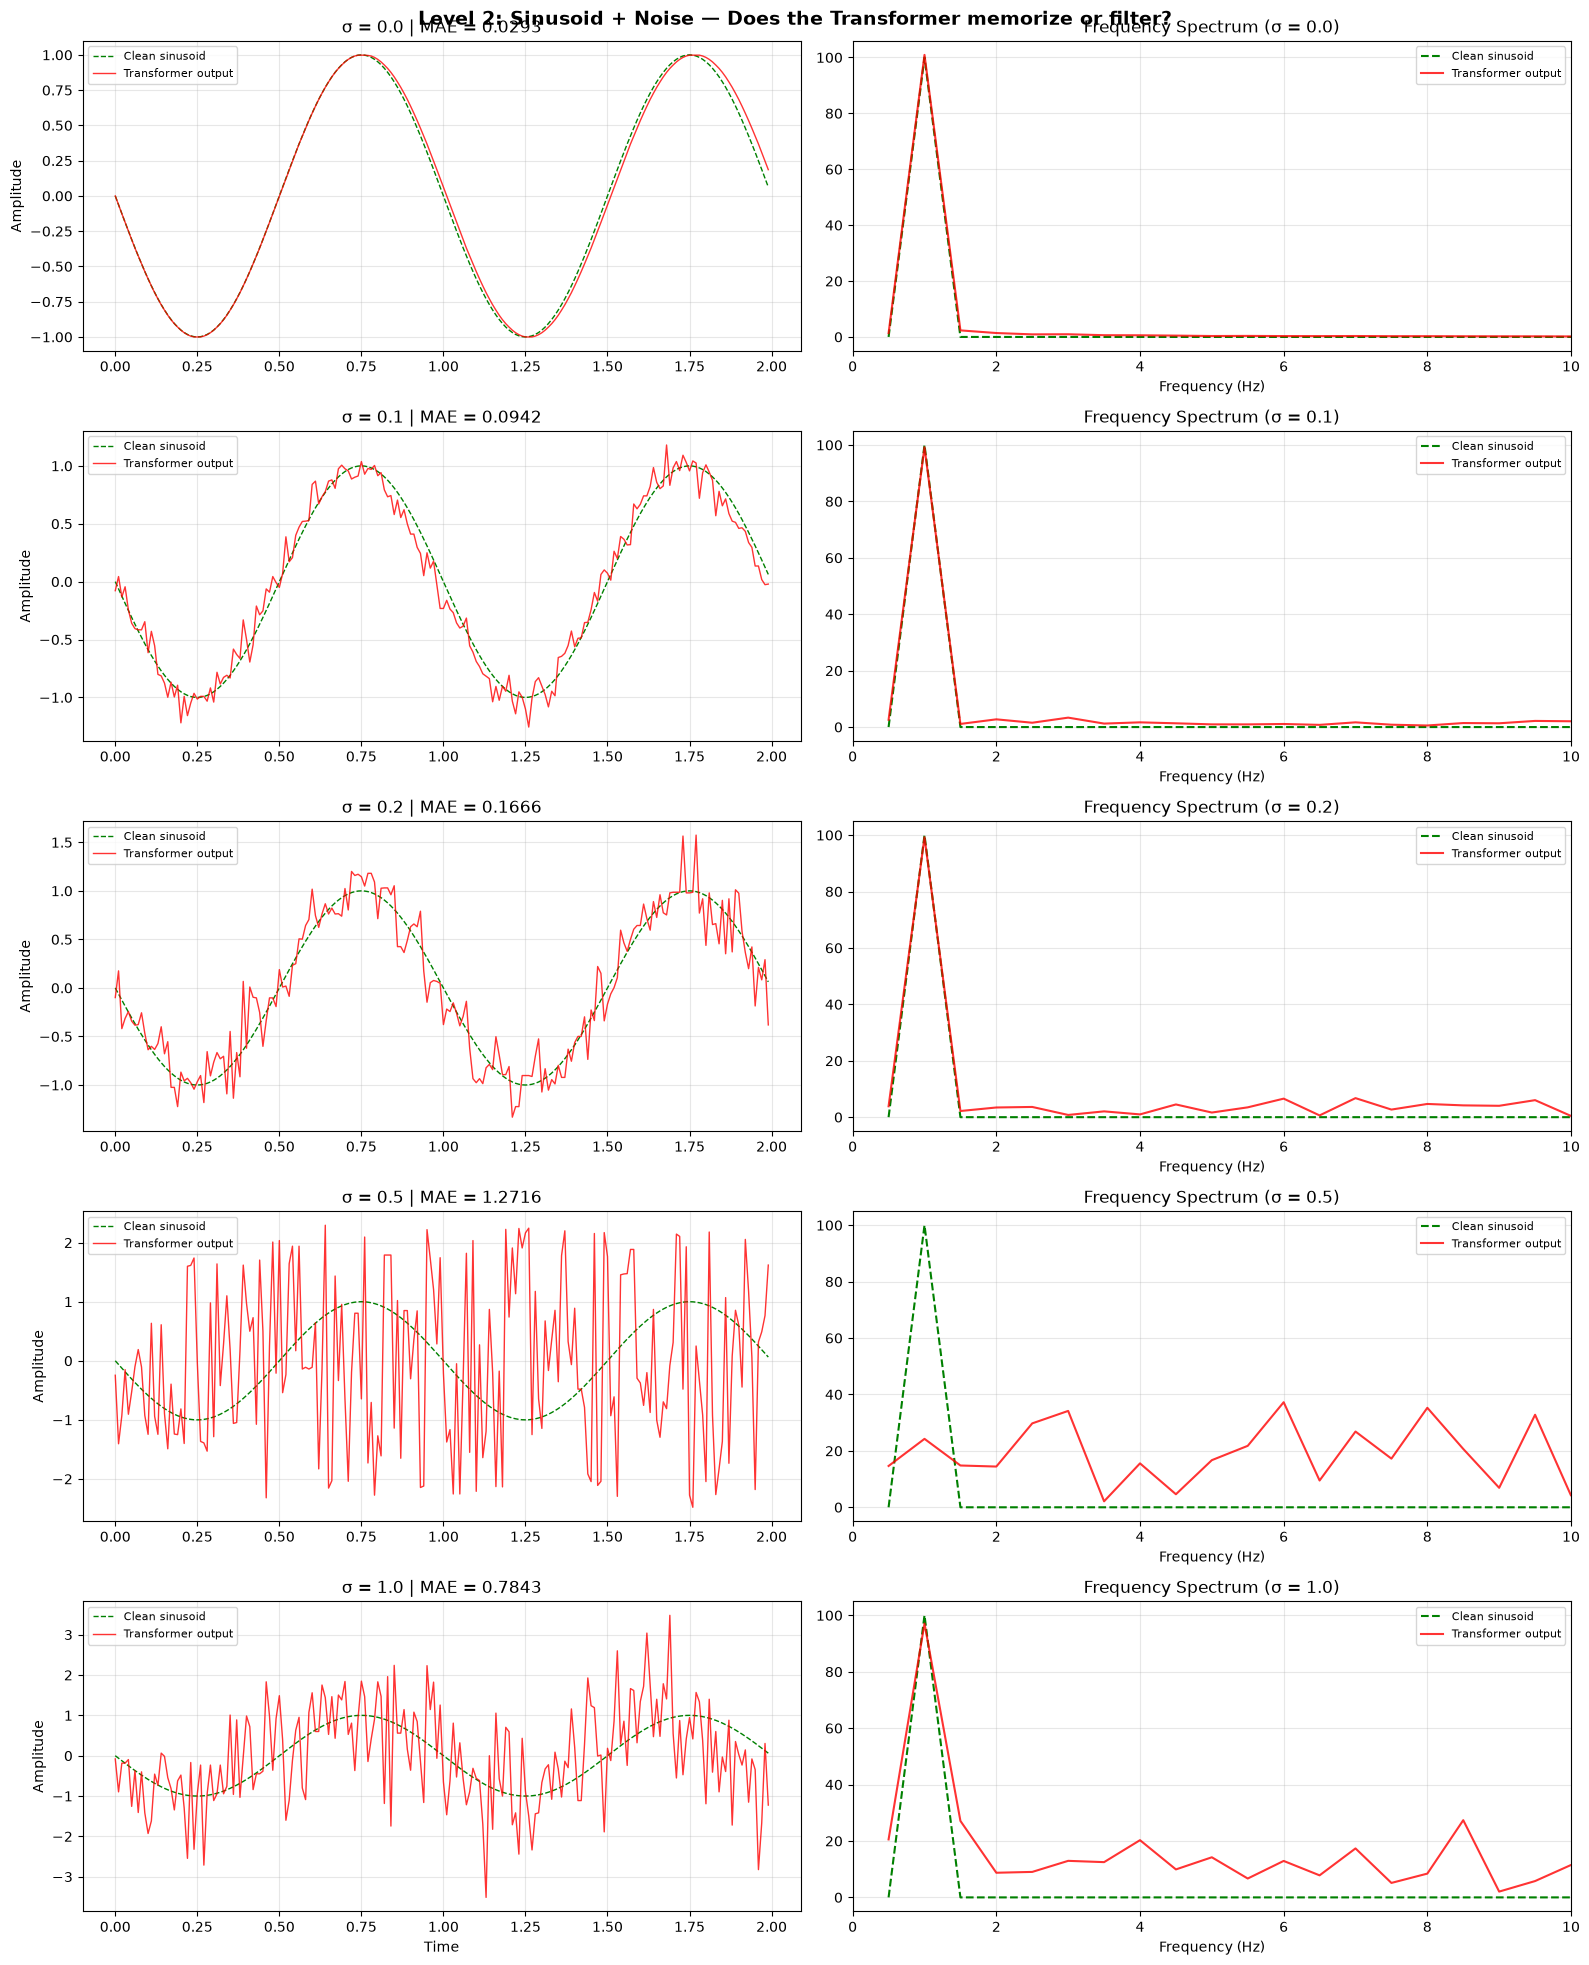

In [8]:
# %% Cell 8 - Visualize Level 2 results

fig, axes = plt.subplots(len(noise_levels), 2, figsize=(16, 4 * len(noise_levels)))

for i, sigma in enumerate(noise_levels):
    r = results_level2[sigma]
    generated = r['generated']
    y_true = r['y_true']
    t = np.arange(len(generated)) * 0.01
    
    # Time domain
    ax = axes[i, 0]
    ax.plot(t[:len(y_true)], y_true[:len(t)], 'g--', linewidth=1, label='Clean sinusoid')
    ax.plot(t, generated[:len(t)], 'r-', linewidth=1, alpha=0.8, label='Transformer output')
    ax.set_title(f'σ = {sigma} | MAE = {r["mae"]:.4f}')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Frequency domain
    ax = axes[i, 1]
    N = min(len(generated), len(y_true))
    freqs = np.fft.fftfreq(N, d=0.01)
    mask = freqs > 0
    
    spectrum_true = np.abs(np.fft.fft(y_true[:N]))
    spectrum_gen = np.abs(np.fft.fft(generated[:N]))
    
    ax.plot(freqs[mask], spectrum_true[mask], 'g--', label='Clean sinusoid')
    ax.plot(freqs[mask], spectrum_gen[mask], 'r-', alpha=0.8, label='Transformer output')
    ax.set_title(f'Frequency Spectrum (σ = {sigma})')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, 10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Time')
plt.suptitle('Level 2: Sinusoid + Noise — Does the Transformer memorize or filter?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.expanduser('~/research-project/plots/sinusoid_level2_comparison.png'), dpi=150)
plt.show()